# 02b — SAM Segmentación sobre Zarr Sentinel-2
**Proyecto:** GeoVisionCLIP-Cali  
**Propósito:** Correr `SamAutomaticMaskGenerator` sobre cada tile `224×224` del Zarr,  
extraer centroides geográficos de cada segmento y guardarlos en un Zarr ligero de metadatos.  
El notebook 02 (v11) leerá este Zarr para asignar etiquetas S5P por segmento en vez de por tile completo.

**Prerequisito:** `sam_vit_b_01ec64.pth` descargado localmente (ya disponible).  
**No modifica** el Zarr de imágenes original — solo escribe `sentinel2_224_masks_meta.zarr` y `sam_segment_meta.json`.


## 0 · Dependencias
```
pip install segment-anything zarr numpy tqdm
```


In [2]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/facebookresearch/segment-anything.git to C:\Users\isape\AppData\Local\Temp\pip-req-build-dohunovb
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36876 sha256=eb25803774101a9d25ce6b73d095742f00ff864bc064d2f1f85c298a36ae26ce
  Stored in directory: C:\Users\isape\AppData\Local\Temp\pip-ephem-wheel-cache-0aejxu5i\wheels\10\cf\59\9ccb2f0a1bcc81d4fbd0e501680b5d088d690c6cfbc02dc99d
Successfully built segm

  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\isape\AppData\Local\Temp\pip-req-build-dohunovb'


In [3]:
import warnings, json, platform
from pathlib import Path
import numpy as np
import zarr
import torch
from tqdm.auto import tqdm

try:
    from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
    print('segment_anything OK')
except ImportError:
    raise ImportError('pip install git+https://github.com/facebookresearch/segment-anything.git')

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')


segment_anything OK
PyTorch : 2.4.1+cu118
CUDA    : True


## 1 · Configuración global


In [9]:
# ── Rutas ──────────────────────────────────────────────────────────────────
ZARR_PATH        = Path(r'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr')
MASKS_META_ZARR  = Path(r'D:\\analitica\\procesado_zarr\\sentinel2_224_masks_meta.zarr')
META_JSON_PATH   = MASKS_META_ZARR.parent / 'sam_segment_meta.json'

# Ruta al checkpoint SAM — apuntar al archivo descargado
SAM_CKPT         = Path(r"C:\Users\isape\OneDrive\Escritorio\ANALITICA\DL - ML\Taller SAM semana 14\sam_vit_b_01ec64.pth")  # ajustar si está en otra carpeta
MODEL_TYPE       = 'vit_b'   # coincide con sam_vit_b_01ec64.pth

# ── Hiperparámetros SAM ─────────────────────────────────────────────────────
# Tiles son 224×224 (mucho más chicos que los 1024 típicos de SAM).
# points_per_side=16 → 256 puntos candidatos. Con crop_n_layers=0 evitamos
# el crop recursivo que SAM usa para imágenes grandes; aquí no hace falta.
POINTS_PER_SIDE        = 16
PRED_IOU_THRESH        = 0.80   # un poco más permisivo que el taller (0.86)
STABILITY_THRESH       = 0.82   # imágenes satelitales tienen bordes suaves
MIN_MASK_AREA_PX       = 150    # filtrar segmentos muy chicos (ruido)
MAX_MASKS_PER_TILE     = 60     # cap para padding del Zarr de salida

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 67   # lineamiento del proyecto: NO usar 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Config cargada.')
print(f'  ZARR_PATH       : {ZARR_PATH}  (existe={ZARR_PATH.exists()})')
print(f'  SAM_CKPT        : {SAM_CKPT}  (existe={SAM_CKPT.exists()})')
print(f'  MASKS_META_ZARR : {MASKS_META_ZARR}')


Config cargada.
  ZARR_PATH       : D:\analitica\procesado_zarr\sentinel2_224.zarr  (existe=True)
  SAM_CKPT        : C:\Users\isape\OneDrive\Escritorio\ANALITICA\DL - ML\Taller SAM semana 14\sam_vit_b_01ec64.pth  (existe=True)
  MASKS_META_ZARR : D:\analitica\procesado_zarr\sentinel2_224_masks_meta.zarr


## 2 · Cargar modelo SAM  
Mismo procedimiento que el `taller_SAM_segmentacion.ipynb`: carga el registry, inyecta el checkpoint, congela.


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

assert SAM_CKPT.exists(), f'Checkpoint no encontrado: {SAM_CKPT}'

sam = sam_model_registry[MODEL_TYPE](checkpoint=str(SAM_CKPT))
sam.eval()
sam = sam.to(device)

total_params = sum(p.numel() for p in sam.parameters())
print(f'SAM cargado: {total_params/1e6:.1f}M parámetros')

# Configurar generador automático
# crop_n_layers=0 desactiva el crop recursivo de SAM para imágenes grandes;
# nuestros tiles de 224×224 no lo necesitan y se ahorra tiempo.
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=POINTS_PER_SIDE,
    pred_iou_thresh=PRED_IOU_THRESH,
    stability_score_thresh=STABILITY_THRESH,
    min_mask_region_area=MIN_MASK_AREA_PX,
    crop_n_layers=0,   # sin crop recursivo para tiles pequeños
)
print('SamAutomaticMaskGenerator listo.')


Dispositivo: cuda
SAM cargado: 93.7M parámetros
SamAutomaticMaskGenerator listo.


## 3 · Abrir Zarr de imágenes S2


In [12]:
import zarr

root_z = zarr.open_group(str(ZARR_PATH), mode='r')

print(root_z.tree())

/
 ├── bbox (363, 4) float64
 ├── escena_id (363,) <U64
 ├── fecha (363,) <U20
 └── images (363, 4, 224, 224) float32


In [14]:
root_z = zarr.open_group(str(ZARR_PATH), mode='r')

# Arrays reales del Zarr
images  = root_z['images']      # (N, 4, 224, 224)
bboxes  = root_z['bbox']        # (N, 4)
fechas  = root_z['fecha']       # (N,)
escenas = root_z['escena_id']   # (N,)

N_TILES = images.shape[0]
H, W    = images.shape[2], images.shape[3]

print(f'Tiles en Zarr    : {N_TILES}')
print(f'Shape imágenes   : {images.shape}  dtype={images.dtype}')
print(f'Shape bboxes     : {bboxes.shape}')
print(f'Rango lon Zarr   : {bboxes[:, 0].min():.4f} → {bboxes[:, 2].max():.4f}')
print(f'Rango lat Zarr   : {bboxes[:, 1].min():.4f} → {bboxes[:, 3].max():.4f}')

Tiles en Zarr    : 363
Shape imágenes   : (363, 4, 224, 224)  dtype=float32
Shape bboxes     : (363, 4)
Rango lon Zarr   : -76.8004 → -75.8122
Rango lat Zarr   : 2.6244 → 4.5235


## 4 · Funciones auxiliares


In [15]:
def tile_to_rgb_uint8(tile_chw: np.ndarray) -> np.ndarray:
    """
    Convierte un tile Sentinel-2 (4, 224, 224) float32 a (224, 224, 3) uint8
    en orden natural de color: B04=R (idx 2), B03=G (idx 1), B02=B (idx 0).

    Normalización por percentil 2-98 para evitar que saturación y sombras
    colapsen el rango dinámico antes de pasarlo a SAM.
    El canal NIR (B08, idx 3) se descarta — SAM no lo usa.
    """
    r = tile_chw[2].astype(np.float32)  # B04 -> canal R
    g = tile_chw[1].astype(np.float32)  # B03 -> canal G
    b = tile_chw[0].astype(np.float32)  # B02 -> canal B
    rgb = np.stack([r, g, b], axis=-1)  # (224, 224, 3)

    # Normalización percentílica robusta (ignora outliers de nubes y sombras)
    p2  = np.percentile(rgb, 2)
    p98 = np.percentile(rgb, 98)
    scale = p98 - p2
    if scale < 1e-8:
        return np.zeros((H, W, 3), dtype=np.uint8)  # tile vacío / todo nube

    rgb_norm = np.clip((rgb - p2) / scale * 255.0, 0, 255).astype(np.uint8)
    return rgb_norm


def pixel_to_geo(row_px: float, col_px: float, bbox, img_h=224, img_w=224):
    """
    Convierte un centroide en píxeles (row, col) a coordenadas geográficas
    (lat, lon) usando el bounding box del tile.

    bbox = [lon_min, lat_min, lon_max, lat_max]
    Nota: lat decrece a medida que row aumenta (norte=fila 0, sur=fila H-1).
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    lon = lon_min + (col_px / img_w) * (lon_max - lon_min)
    lat = lat_max - (row_px / img_h) * (lat_max - lat_min)
    return float(lat), float(lon)


def extract_segment_meta(masks_auto: list, bbox, img_h=224, img_w=224) -> list:
    """
    De la lista de máscaras de SamAutomaticMaskGenerator, extrae:
    - centroide geográfico (lat, lon)
    - área en píxeles
    - stability_score y predicted_iou de SAM

    Retorna lista de dicts ordenada por área descendente.
    """
    segments = []
    for m in masks_auto:
        seg_mask = m['segmentation']   # (H, W) bool
        ys, xs = np.where(seg_mask)
        if len(ys) == 0:
            continue
        cy = float(ys.mean())
        cx = float(xs.mean())
        lat, lon = pixel_to_geo(cy, cx, bbox, img_h, img_w)
        segments.append({
            'centroid_lat'    : lat,
            'centroid_lon'    : lon,
            'area_px'         : int(m['area']),
            'stability_score' : float(m['stability_score']),
            'predicted_iou'   : float(m['predicted_iou']),
        })
    segments.sort(key=lambda s: s['area_px'], reverse=True)
    return segments


## 5 · Segmentación de todos los tiles  

El loop itera sobre los `N_TILES` tiles.  
Para cada uno:  
1. Convierte el tile float32 a RGB uint8 con normalización percentílica.  
2. Corre `mask_generator.generate()` (Image Encoder ejecuta una vez por tile).  
3. Extrae centroides geográficos de cada segmento.  

Tiempo estimado: ~0.5 s/tile en GPU, ~3-5 s/tile en CPU.  
Para 363 tiles: ~3-30 min según hardware.


In [16]:
tile_metas = []   # lista final: un dict por tile
n_tiles_sin_mascaras = 0

for tile_idx in tqdm(range(N_TILES), desc='SAM segmentación'):

    # ── Cargar tile y convertir a RGB uint8 ──────────────────────────────
    tile_chw = images[tile_idx]          # (4, 224, 224) float32
    bbox_i   = bboxes[tile_idx]          # [lon_min, lat_min, lon_max, lat_max]
    rgb_uint8 = tile_to_rgb_uint8(tile_chw)  # (224, 224, 3) uint8

    # ── Saltar tile vacío (todo ceros tras normalización) ─────────────────
    if rgb_uint8.sum() == 0:
        tile_metas.append({'tile_idx': int(tile_idx), 'n_segments': 0, 'segments': []})
        n_tiles_sin_mascaras += 1
        continue

    # ── Segmentación SAM ──────────────────────────────────────────────────
    with torch.no_grad():
        masks_auto = mask_generator.generate(rgb_uint8)

    # ── Extraer metadatos de segmentos ────────────────────────────────────
    segments = extract_segment_meta(masks_auto, bbox_i, H, W)

    # Cap para evitar tiles con demasiados segmentos (ruido textural)
    segments = segments[:MAX_MASKS_PER_TILE]

    tile_metas.append({
        'tile_idx'  : int(tile_idx),
        'n_segments': len(segments),
        'segments'  : segments,
    })

print(f'\nSegmentación completa.')
print(f'  Tiles procesados          : {len(tile_metas)}')
print(f'  Tiles sin máscaras        : {n_tiles_sin_mascaras}')
n_segs_total = sum(t["n_segments"] for t in tile_metas)
print(f'  Segmentos totales         : {n_segs_total}')
print(f'  Promedio segmentos/tile   : {n_segs_total / max(1, len(tile_metas) - n_tiles_sin_mascaras):.1f}')


SAM segmentación:   0%|          | 0/363 [00:00<?, ?it/s]


Segmentación completa.
  Tiles procesados          : 363
  Tiles sin máscaras        : 0
  Segmentos totales         : 7844
  Promedio segmentos/tile   : 21.6


## 6 · Guardar resultados  
Dos formatos en paralelo:  
- **`sam_segment_meta.json`** — legible, útil para depuración y visualización.  
- **`sentinel2_224_masks_meta.zarr`** — arrays numpy para lookup vectorizado rápido desde el notebook 02.


In [17]:
import platform

# ── 6a. JSON ─────────────────────────────────────────────────────────────
META_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(META_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(tile_metas, f, ensure_ascii=False, indent=2)
print(f'JSON guardado: {META_JSON_PATH}  ({META_JSON_PATH.stat().st_size / 1e6:.2f} MB)')

# ── 6b. Zarr de arrays (para lookup rápido desde NB 02) ──────────────────
# Estructura de padding:
#   n_masks    (N_TILES,)            int32  — cuántos segmentos válidos por tile
#   cent_lat   (N_TILES, MAX_SEGS)   float32 — lat del centroide; NaN si no hay
#   cent_lon   (N_TILES, MAX_SEGS)   float32
#   areas      (N_TILES, MAX_SEGS)   int32   — área en px; 0 si no hay

max_segs = max((t['n_segments'] for t in tile_metas), default=1)
max_segs = min(max_segs, MAX_MASKS_PER_TILE)

n_masks_arr = np.zeros(N_TILES, dtype=np.int32)
cent_lat_arr = np.full((N_TILES, max_segs), np.nan, dtype=np.float32)
cent_lon_arr = np.full((N_TILES, max_segs), np.nan, dtype=np.float32)
areas_arr    = np.zeros((N_TILES, max_segs), dtype=np.int32)

for t in tile_metas:
    ti = t['tile_idx']
    n_masks_arr[ti] = t['n_segments']
    for si, seg in enumerate(t['segments'][:max_segs]):
        cent_lat_arr[ti, si] = seg['centroid_lat']
        cent_lon_arr[ti, si] = seg['centroid_lon']
        areas_arr[ti, si]    = seg['area_px']

MASKS_META_ZARR.mkdir(parents=True, exist_ok=True) if not MASKS_META_ZARR.exists() else None
root_out = zarr.open_group(str(MASKS_META_ZARR), mode='w')
root_out['n_masks']     = n_masks_arr
root_out['centroid_lat'] = cent_lat_arr
root_out['centroid_lon'] = cent_lon_arr
root_out['areas']        = areas_arr
root_out.attrs['max_segs']     = int(max_segs)
root_out.attrs['n_tiles']      = int(N_TILES)
root_out.attrs['sam_model']    = MODEL_TYPE
root_out.attrs['points_per_side'] = POINTS_PER_SIDE
root_out.attrs['min_mask_area_px'] = MIN_MASK_AREA_PX

print(f'Zarr de máscaras guardado: {MASKS_META_ZARR}')
print(f'  n_masks     shape={n_masks_arr.shape}')
print(f'  centroid_lat shape={cent_lat_arr.shape}')
print(f'  max_segs     = {max_segs}')


JSON guardado: D:\analitica\procesado_zarr\sam_segment_meta.json  (1.77 MB)
Zarr de máscaras guardado: D:\analitica\procesado_zarr\sentinel2_224_masks_meta.zarr
  n_masks     shape=(363,)
  centroid_lat shape=(363, 48)
  max_segs     = 48


## 7 · Verificación rápida  
Seleccionar 5 tiles aleatorios y mostrar cuántos segmentos tienen.


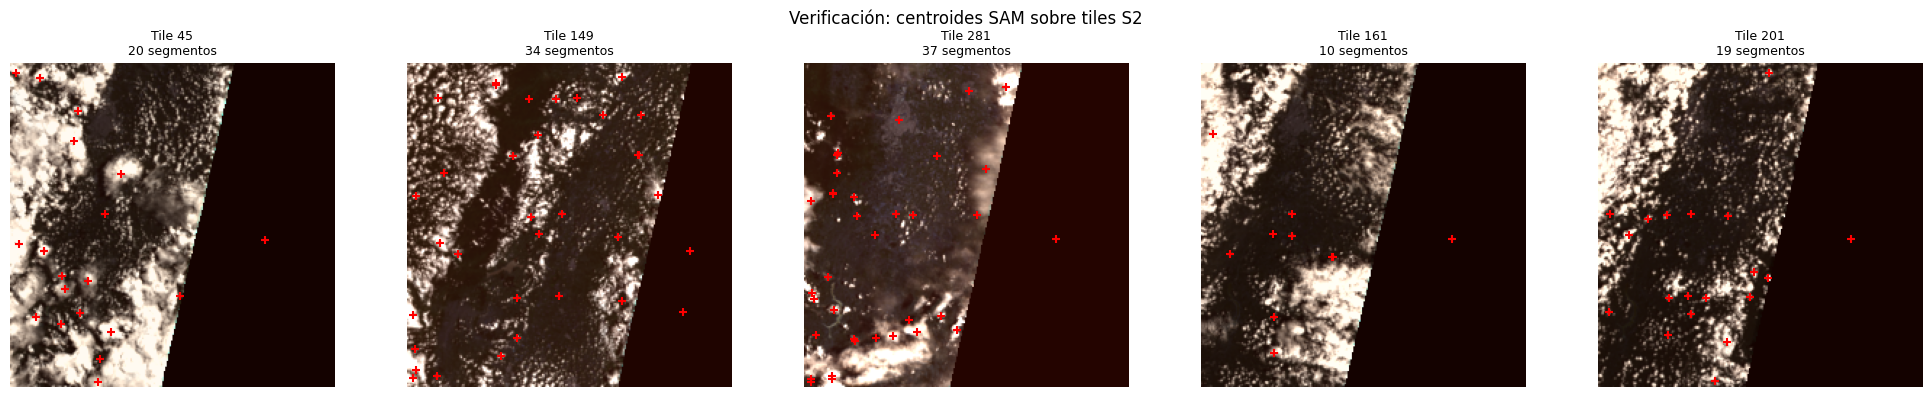

Verificación completada.


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

rng = np.random.default_rng(SEED)
sample_idxs = rng.choice(N_TILES, size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, ti in zip(axes, sample_idxs):
    rgb = tile_to_rgb_uint8(images[ti])
    ax.imshow(rgb)
    n_seg = tile_metas[ti]['n_segments']
    # Marcar centroides
    bbox_i = bboxes[ti]
    for si in range(n_seg):
        lat = cent_lat_arr[ti, si]
        lon = cent_lon_arr[ti, si]
        lon_min, lat_min, lon_max, lat_max = bbox_i
        col_px = (lon - lon_min) / (lon_max - lon_min + 1e-10) * W
        row_px = (lat_max - lat) / (lat_max - lat_min + 1e-10) * H
        ax.plot(col_px, row_px, 'r+', markersize=6, markeredgewidth=1.5)
    ax.set_title(f'Tile {ti}\n{n_seg} segmentos', fontsize=9)
    ax.axis('off')

plt.suptitle('Verificación: centroides SAM sobre tiles S2', fontsize=12)
plt.tight_layout()
plt.savefig(MASKS_META_ZARR.parent / 'sam_centroids_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('Verificación completada.')


## 8 · Resumen de distribución de segmentos


Distribución de segmentos por tile:
  Min    : 3
  Max    : 48
  Mediana: 21
  Media  : 21.6
  Tiles con 0 segmentos: 0
  Tiles con ≥5 segmentos: 361


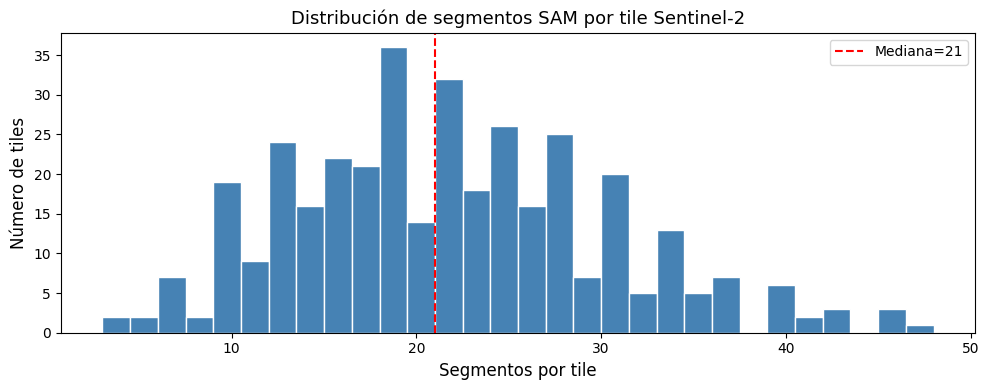

In [19]:
n_segs_por_tile = [t['n_segments'] for t in tile_metas]
print('Distribución de segmentos por tile:')
print(f'  Min    : {min(n_segs_por_tile)}')
print(f'  Max    : {max(n_segs_por_tile)}')
print(f'  Mediana: {np.median(n_segs_por_tile):.0f}')
print(f'  Media  : {np.mean(n_segs_por_tile):.1f}')
print(f'  Tiles con 0 segmentos: {sum(1 for n in n_segs_por_tile if n == 0)}')
print(f'  Tiles con ≥5 segmentos: {sum(1 for n in n_segs_por_tile if n >= 5)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(n_segs_por_tile, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Segmentos por tile', fontsize=12)
ax.set_ylabel('Número de tiles', fontsize=12)
ax.set_title('Distribución de segmentos SAM por tile Sentinel-2', fontsize=13)
ax.axvline(np.median(n_segs_por_tile), color='red', linestyle='--', label=f'Mediana={np.median(n_segs_por_tile):.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(MASKS_META_ZARR.parent / 'sam_segs_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()
